In [172]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [173]:
import os

import pandas as pd
from pathlib import Path

from PIL import Image
import torch

import warnings
warnings.filterwarnings("ignore")

In [174]:
DATA_DIR = Path.cwd().parent.resolve() / "data"
metadata_dir = DATA_DIR / "GF1_B02_B03_B04_B08_Mask"
metadata_path = metadata_dir / "metadata.csv"

In [175]:
df = pd.read_csv(metadata_path)
df.head()

,filename,location,datetime,path
0,GF1_WFV1_E102.0_N28.0_20140302_L2A0000280476,E102.0-N28.0,2014/3/2,C:\Users\gaoha\PycharmProjects\PythonProject\d...
1,GF1_WFV1_E104.1_S0.6_20151012_L2A0001096133,E104.1-S0.6,2015/10/12,C:\Users\gaoha\PycharmProjects\PythonProject\d...
2,GF1_WFV1_E104.3_N12.9_20140522_L2A0000356326,E104.3-N12.9,2014/5/22,C:\Users\gaoha\PycharmProjects\PythonProject\d...
3,GF1_WFV1_E104.8_N51.3_20150617_L2A0000979951,E104.8-N51.3,2015/6/17,C:\Users\gaoha\PycharmProjects\PythonProject\d...
4,GF1_WFV1_E114.4_N38.0_20130505_L2A0000029007,E114.4-N38.0,2013/5/5,C:\Users\gaoha\PycharmProjects\PythonProject\d...


In [176]:
metadata = list(metadata_dir.glob("*.tif"))
metadata

[PosixPath('/Users/hangzegao/PycharmProjects/cloud/data/GF1_B02_B03_B04_B08_Mask/GF1_WFV4_W155.2_N20.2_20160721_L2A0001718813.tif'),
 PosixPath('/Users/hangzegao/PycharmProjects/cloud/data/GF1_B02_B03_B04_B08_Mask/GF1_WFV4_E89.3_N43.4_20130714_L2A0000063081.tif')]

In [177]:
def update_path(row):
    file_suffix = ".tif"
    filename = row["filename"] + file_suffix
    path = os.path.join(metadata_dir, filename)
    return path

df["path"] = df.apply(update_path, axis=1)
df = df[df["path"].apply(os.path.exists)]
df.head(100)

,filename,location,datetime,path
98,GF1_WFV4_E89.3_N43.4_20130714_L2A0000063081,E89.3-N43.4,2013/7/14,/Users/hangzegao/PycharmProjects/cloud/data/GF...
101,GF1_WFV4_W155.2_N20.2_20160721_L2A0001718813,W155.2-N20.2,2016/7/21,/Users/hangzegao/PycharmProjects/cloud/data/GF...


In [178]:
import math
from tqdm import tqdm
import pandas as pd
from loguru import logger
from pathlib import Path
import numpy as np
from functools import partial
import concurrent
from typing import Dict, Any, List
import rasterio

from MyCloudSenseNet.benchmark.cloud_dataset import CloudDataset
from MyCloudSenseNet.benchmark.cloud_model import CloudModel

BANDS = ["B02", "B03", "B04", "B08"]
CHIP_SIZE = 512
OVERLAP_RATIO = 0.2
VALID_THRESHOLD = [0.001, 0.999]
DATA_DIR = Path.cwd().parent.resolve() / "data"
MODEL_NAME = "unet"


def mask2label(mask):
    label = np.zeros_like(mask, dtype=np.uint8)
    label[(mask >= 0) & (mask <= 50)] = 0  # background
    label[(mask >= 100) & (mask <= 200)] = 1  # shadow
    label[(mask >= 250) & (mask <= 255)] = 2  # cloud
    return label

def stretch(arr, p=2, a_min=0, a_max=1):
    lo = np.percentile(arr, p)
    hi = np.percentile(arr, 100 - p)
    return np.clip((arr - lo) / (hi - lo), a_min, a_max)


def is_label_valid(label: np.ndarray, valid_threshold: List[float] = VALID_THRESHOLD) -> bool:
    valid_pixel = np.sum((label > 0.01) & (label <= 2.0))
    total_pixel = label.size
    valid_percent = valid_pixel / total_pixel
    return valid_threshold[0] <= valid_percent <= valid_threshold[1]


class GeoTIFFTiler:
    def __init__(self, df_row: pd.Series, is_for_training: bool = True, display_thumbnail: bool = False):
        self.df_row = df_row
        self.info = None
        self.is_for_training = is_for_training
        self._read(display_thumbnail)

    def _read(self, display_thumbnail: bool):
        with rasterio.open(self.df_row.path) as src:
            data = src.read((1, 2, 3, 4))
            mask = src.read((5))
            self.info = {
                "data": data,
                "bit": int(math.log2(data.max() + 1)),
                "label": mask2label(mask),
                "meta": src.meta.copy(),
                "transform": src.transform,
                "crs": src.crs,
                "height": src.height,
                "width": src.width,
            }
            if display_thumbnail:
                self._display_thumbnail(src)

    def _display_thumbnail(self, src):
        max_size = 512
        h, w = src.height, src.width
        scale = min(max_size / w, max_size / h)
        new_w, new_h = int(w * scale), int(h * scale)
        thumbnail = src.read(out_shape=(src.count, new_h, new_w),
                             resampling=rasterio.enums.Resampling.bilinear)

        name = Path(self.df_row.path).stem
        b, g, r, nir, mask = thumbnail[:5]
        rgb = stretch(np.dstack((r, g, b)))

        fig, ax = plt.subplots(1, 2, figsize=(8, 4))
        logger.debug(name)
        fig.suptitle(name, fontsize=14, fontweight="bold")

        ax[0].imshow(rgb)
        ax[0].set_title("RGB Image")

        ax[1].imshow(mask)
        ax[1].set_title("Mask Image")

        plt.tight_layout()
        plt.show()

    def calculate_transform(self, x_start: int, y_start: int, x_end: int, y_end: int, chip_size: int) -> rasterio.Affine:
        orig_transform = self.info["transform"]
        x_min = orig_transform.xoff + x_start * orig_transform.a
        y_max = orig_transform.yoff + y_start * orig_transform.e
        x_max = orig_transform.xoff + x_end * orig_transform.a
        y_min = orig_transform.yoff + y_end * orig_transform.e

        return rasterio.transform.from_bounds(x_min, y_min, x_max, y_max, chip_size, chip_size)

    def generate_chip_windows(self, chip_size=CHIP_SIZE, overlap_ratio=OVERLAP_RATIO):
        stride = int(chip_size * (1 - overlap_ratio))
        height, width = self.info.get("height", 0), self.info.get("width", 0)
        windows = []
        chip_idx = 0

        # Row-wise
        y_start = 0
        while y_start < height:
            y_end = min(y_start + chip_size, height)

            # Column-wise
            x_start = 0
            while x_start < width:
                x_end = min(x_start + chip_size, width)

                chip_id = f"{self.df_row.filename}_chip_{chip_idx:04d}"
                windows.append({
                    "chip_idx": chip_idx,
                    "chip_id": chip_id,
                    "chip_size": chip_size,
                    "x_start": x_start,
                    "x_end": x_end,
                    "y_start": y_start,
                    "y_end": y_end,
                    "transform": self.calculate_transform(x_start, y_start, x_end, y_end, chip_size),
                })

                x_start += stride
                chip_idx += 1
            y_start += stride

        self.info["windows"] = windows

        logger.info(f"Generating overlapping windows: Total {len(windows)} chips | Overlap ratio {overlap_ratio * 100:.0f}% | Stride {stride}")

    def save_chip(self, chip_data: np.ndarray, chip_label: np.ndarray, chip_info: Dict[str, Any], output_dirs: Dict[str, Path]) -> Dict[str, str]:
        chip_id = chip_info["chip_id"]
        chip_size = chip_info["chip_size"]
        chip_dir = output_dirs["img"] / chip_id
        chip_dir.mkdir(exist_ok=True, parents=True)
        label_out_dir = output_dirs["label"]
        label_out_dir.mkdir(exist_ok=True, parents=True)

        meta = {
            "driver": "GTiff",
            "height": chip_size,
            "width": chip_size,
            "count": 1,
            "dtype": "uint16",
            "crs": chip_info["crs"],
            "transform": chip_info["transform"],
            "compress": "deflate",
            "predictor": 2,
        }

        paths = {}
        for idx, band in enumerate(BANDS):
            path = chip_dir / f"{band}.tif"
            if not path.exists():
                with rasterio.open(path, "w", **meta) as dst:
                    dst.write(chip_data[idx], 1)
            paths[f"{band}_path"] = str(path.resolve())

        path = label_out_dir / f"{chip_id}.tif"
        if not path.exists():
            with rasterio.open(path, "w", **meta) as dst:
                dst.write(chip_label, 1)
        paths[r"label_path"] = str(path.resolve())
        return paths

    def get_single_chip(self, window: Dict[str, Any], full_data: np.ndarray, full_label: np.ndarray, output_dirs: Dict[str, Path]) -> Dict[str, Any]:
        x1, x2 = window["x_start"], window["x_end"]
        y1, y2 = window["y_start"], window["y_end"]

        chip_label = full_label[y1:y2, x1:x2]

        if self.is_for_training and not is_label_valid(chip_label):
            return None

        chip_data = full_data[:, y1:y2, x1:x2]

        chip_info = {
            "chip_id": window["chip_id"],
            "chip_size": window["chip_size"],
            "transform": window["transform"],
            "crs": self.info["crs"],
            "x_start": x1, "x_end": x2,
            "y_start": y1, "y_end": y2
        }

        paths = self.save_chip(chip_data, chip_label, chip_info, output_dirs)

        return {
            "chip_id": window["chip_id"],
            "location": self.df_row.location,
            "datetime": self.df_row.datetime,
            "x_start": x1, "x_end": x2,
            "y_start": y1, "y_end": y2,
            **paths,
        }

    def get_chips(self, csv_out_dir: Path, img_out_dir: Path, label_out_dir: Path, max_workers: int = 4) -> None:
        chip_size = CHIP_SIZE
        # if not self.is_for_training:
        #     chip_size = CHIP_SIZE * 2
        self.generate_chip_windows(chip_size=chip_size)
        csv_out_dir.mkdir(exist_ok=True, parents=True)
        img_out_dir.mkdir(exist_ok=True, parents=True)
        label_out_dir.mkdir(exist_ok=True, parents=True)

        filename = self.df_row.filename
        img_chip_out_dir = img_out_dir / filename
        label_chip_out_dir = label_out_dir / filename

        img_chip_out_dir.mkdir(exist_ok=True, parents=True)
        label_chip_out_dir.mkdir(exist_ok=True, parents=True)

        output_dirs = {
            "img": img_chip_out_dir,
            "label": label_chip_out_dir
        }

        metadata = []
        windows = self.info["windows"]
        with concurrent.futures.ThreadPoolExecutor(max_workers=max_workers) as executor:
            process_func = partial(
                self.get_single_chip,
                full_data=self.info["data"],
                full_label=self.info["label"],
                output_dirs=output_dirs
            )
            futures = {executor.submit(process_func, win): win for win in windows}

            for future in tqdm(concurrent.futures.as_completed(futures), total=len(windows), desc="Processing chips"):
                result = future.result()
                if result:
                    metadata.append(result)

        chip_df = pd.DataFrame(metadata)
        self.info["metadata"] = chip_df
        chip_df.to_csv(csv_out_dir / f"{filename}_metadata.csv", index=False)
        logger.info(f"Process {filename} completed! Generated {len(metadata)} valid chips.")

    def predict_chips(self, pred_out_dir: Path, fast_dev_run: bool = False):
        logger.info("Loading model weights")
        model_weights_path: Path = Path(f"benchmark/{MODEL_NAME}/assets/cloud_model.pt")

        logger.info("Loading model")
        model = CloudModel(bands=BANDS,
                           hparams={"weights": None},
                           model_name=MODEL_NAME)
        model.load_state_dict(torch.load(model_weights_path))

        logger.info("Loading metadata")
        x_paths = self.info["metadata"]
        if fast_dev_run:
            x_paths = x_paths.head(model.num_workers * model.num_workers)
        logger.info(f"Found {len(x_paths)} chips")

        dataset = CloudDataset(x_paths=x_paths, bands=BANDS)
        dataloader = torch.utils.data.DataLoader(dataset,
                                                 batch_size=model.batch_size,
                                                 num_workers=model.num_workers,
                                                 pin_memory=False)

        logger.info("Generating predictions in batches")
        for batch_index, batch in enumerate(dataloader):
            if batch_index % 30 == 0:
                logger.debug(f"Predicting batch {batch_index} of {len(dataloader)}")
            device = next(model.parameters()).device
            x = batch["chip"].to(device)
            model.eval()
            with torch.no_grad():
                preds = model(x)
                preds = torch.argmax(preds, dim=1).cpu().numpy().astype("uint8")
            # preds = model.forward(x)
            # preds = torch.softmax(preds, dim=1)[:, 1]
            # preds = (preds > 0.5).detach().numpy().astype("uint8")
            # preds = torch.argmax(preds, dim=1).detach().numpy().astype("uint8")
            for chip_id, pred in zip(batch["chip_id"], preds):
                chip_pred_path = pred_out_dir / f"{chip_id}.tif"
                chip_pred_im = Image.fromarray(pred)
                chip_pred_im.save(chip_pred_path)

        logger.info(f"""Saved {len(list(pred_out_dir.glob("*.tif")))} predictions""")

    def predict(self, pred_out_dir: Path = DATA_DIR / "predictions", fusion_method: str = "vote", fast_dev_run: bool = False):
        logger.info("Starting predicting chips")
        pred_label_dir = pred_out_dir / self.df_row.filename
        pred_label_dir.mkdir(exist_ok=True, parents=True)
        self.predict_chips(pred_label_dir, fast_dev_run)

        windows = self.info["windows"]
        height, width = self.info["height"], self.info["width"]
        meta, crs, transform = self.info["meta"], self.info["crs"], self.info["transform"]

        # pred_full：Used to store the restored prediction results
        # weight_full：Used to record the number of times each pixel is covered (for overlay blending)
        pred_full = np.zeros((height, width), dtype=np.float32)
        weight_full = np.zeros((height, width), dtype=np.float32)

        logger.info("Starting restoring predicted chips to a large image")
        for win in tqdm(windows, total=len(windows), desc="restoring"):
            x1, y1 = int(win["x_start"]), int(win["y_start"])
            x2, y2 = int(win["x_end"]), int(win["y_end"])
            chip_pred_path = Path(pred_label_dir) / f"{win['chip_id']}.tif"
            if not chip_pred_path.exists():
                continue
            with rasterio.open(chip_pred_path) as src:
                chip_pred = src.read(1)

            chip_h, chip_w = y2 - y1, x2 - x1
            pred_full[y1:y2, x1:x2] += chip_pred[:chip_h, :chip_w]
            weight_full[y1:y2, x1:x2] += 1

        weight_full[weight_full == 0] = 1

        if fusion_method == "average":
            pred_full = pred_full / weight_full
        elif fusion_method == "vote":
            pred_full = np.round(pred_full / weight_full).astype(np.int32)

        logger.info("Saving prediction results as GeoTIFF with geographic coordinates")
        meta.update({
            "count": 1,
            "dtype": np.uint8,  # pred_full.dtype,
            "height": height,
            "width": width,
            "crs": crs,
            "transform": transform,
            "compress": "deflate",
            "predictor": 2,
        })

        pred_out_path = pred_out_dir / f"{self.df_row.filename}_PredictedMask.tif"
        with rasterio.open(pred_out_path, "w", **meta) as dst:
            dst.write(pred_full, 1)

        logger.info("Restoration completed!")

In [179]:
CSV_OUT_DIR = DATA_DIR / "metadata"
IMG_OUT_DIR = DATA_DIR / "images"
LABEL_OUT_DIR = DATA_DIR / "labels"
PRED_OUT_DIR = DATA_DIR / "predictions"

# Select the module in training or testing mode.

In [180]:
# train or test
# mode = "training"
mode = "testing"

# Generate training chips

In [181]:
training_targets_txt = CSV_OUT_DIR / "training_targets.txt"
with open(training_targets_txt, 'r', encoding='utf-8') as f:
    training_targets = [line.strip() for line in f if line.strip()]
training_targets

['GF1_WFV4_E89.3_N43.4_20130714_L2A0000063081']

In [182]:
df_for_training = df[df["filename"].isin(training_targets)].copy()
df_for_training

,filename,location,datetime,path
98,GF1_WFV4_E89.3_N43.4_20130714_L2A0000063081,E89.3-N43.4,2013/7/14,/Users/hangzegao/PycharmProjects/cloud/data/GF...


In [183]:
if mode == "training":
    for i in range(len(df_for_training)):
        t = GeoTIFFTiler(df_row=df_for_training.iloc[i], is_for_training=True, display_thumbnail=True)
        t.get_chips(CSV_OUT_DIR, IMG_OUT_DIR, LABEL_OUT_DIR)

# Generate testing chips

In [184]:
testing_targets_txt = CSV_OUT_DIR / "testing_targets.txt"
with open(testing_targets_txt, 'r', encoding='utf-8') as f:
    testing_targets = [line.strip() for line in f if line.strip()]
testing_targets

['GF1_WFV4_W155.2_N20.2_20160721_L2A0001718813', '#HRC_WHU']

In [185]:
df_for_testing = df[df["filename"].isin(testing_targets)].copy()
df_for_testing

,filename,location,datetime,path
101,GF1_WFV4_W155.2_N20.2_20160721_L2A0001718813,W155.2-N20.2,2016/7/21,/Users/hangzegao/PycharmProjects/cloud/data/GF...


2026-05-24 22:07:19.640 | DEBUG    | __main__:_display_thumbnail:80 - GF1_WFV4_W155.2_N20.2_20160721_L2A0001718813


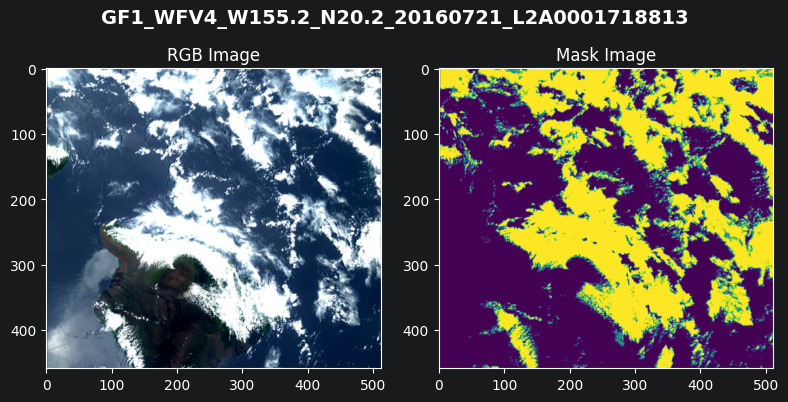

2026-05-24 22:07:19.887 | INFO     | __main__:generate_chip_windows:135 - Generating overlapping windows: Total 1188 chips | Overlap ratio 20% | Stride 409
Processing chips: 100%|██████████| 1188/1188 [00:00<00:00, 3410.65it/s]
2026-05-24 22:07:20.278 | INFO     | __main__:get_chips:243 - Process GF1_WFV4_W155.2_N20.2_20160721_L2A0001718813 completed! Generated 1188 valid chips.
2026-05-24 22:07:20.278 | INFO     | __main__:predict:289 - Starting predicting chips
2026-05-24 22:07:20.279 | INFO     | __main__:predict_chips:246 - Loading model weights
2026-05-24 22:07:20.279 | INFO     | __main__:predict_chips:249 - Loading model
2026-05-24 22:07:20.960 | INFO     | __main__:predict_chips:255 - Loading metadata
2026-05-24 22:07:20.960 | INFO     | __main__:predict_chips:259 - Found 1188 chips
2026-05-24 22:07:20.965 | INFO     | __main__:predict_chips:267 - Generating predictions in batches
2026-05-24 22:07:21.047 | DEBUG    | __main__:predict_chips:270 - Predicting batch 0 of 297
2026-0

In [186]:
import traceback

try:
    if mode == "testing":
        for i in range(len(df_for_testing)):
            t = GeoTIFFTiler(df_row=df_for_testing.iloc[i], is_for_training=False, display_thumbnail=True)
            t.get_chips(CSV_OUT_DIR, IMG_OUT_DIR, LABEL_OUT_DIR)
            t.predict(PRED_OUT_DIR, fast_dev_run=False)
except Exception as e:
    traceback.print_exc()

In [187]:
from matplotlib import pyplot as plt
from pathlib import Path
import numpy as np
import rasterio
import traceback


def intersection_over_union_and_coverage(pred, true, n_classes=3):
    """
    Calculates intersection and union for a batch of images.
    Calculates coverage of each class for a batch of images.
    """
    total_pixels = true.size
    valid_pixel_mask = (true != 255)  # valid pixel mask
    true = true[valid_pixel_mask]
    pred = pred[valid_pixel_mask]

    iou_list = []
    true_coverage_list = []
    pred_coverage_list = []
    for cls in range(n_classes):
        # skip background
        if cls == 0:
            continue

        # Prediction/ground truth mask of the current category
        true_cls = (true == cls)
        pred_cls = (pred == cls)

        # Intersection and union totals
        intersection = np.logical_and(true_cls, pred_cls)
        union = np.logical_or(true_cls, pred_cls)

        iou = intersection.sum() / (union.sum() + 1e-8)
        iou_list.append(min(iou, 1))

        true_coverage = true_cls.sum() / total_pixels
        pred_coverage = pred_cls.sum() / total_pixels
        true_coverage_list.append(true_coverage)
        pred_coverage_list.append(pred_coverage)

    mIoU = np.mean(iou_list)

    return mIoU, true_coverage_list, pred_coverage_list

def display_thumbnail_more(data_path, pred_path=None, max_size=512):
    logger.info(f"Displaying thumbnail for {data_path.name}")
    with rasterio.open(data_path) as src:
        true = mask2label(src.read(5).astype(np.uint8))

        h, w = src.height, src.width
        scale = min(max_size / w, max_size / h)
        new_w, new_h = int(w * scale), int(h * scale)
        data = src.read(out_shape=(src.count, new_h, new_w),
                        resampling=rasterio.enums.Resampling.bilinear)

    b = data[0]
    g = data[1]
    r = data[2]
    nir = data[3]
    mask = data[4]
    rgb = np.dstack((r, g, b))

    rgb = stretch(rgb)

    fig, ax = plt.subplots(1, 3, figsize=(24, 8))


    ax[0].imshow(rgb)
    ax[0].set_title("RGB Image")

    ax[1].imshow(mask)
    ax[1].set_title("True Mask Image")

    if pred_path:
        with rasterio.open(pred_path) as src2:
            pred = src2.read(1).astype(np.uint8)
            pred_mask = src2.read(indexes=(1),
                                  out_shape=(src2.count, new_h, new_w),
                                  resampling=rasterio.enums.Resampling.bilinear).astype(np.uint8)

        iou, true_cov, pred_cov = intersection_over_union_and_coverage(pred, true)

        ax[1].set_title(f"True Mask Image\nshadow coverage={true_cov[0]:04f} | cloud coverage={true_cov[1]:04f} ")
        ax[2].imshow(pred_mask)
        ax[2].set_title(f"Predicted Mask Image with iou={iou:04f}\nshadow coverage={pred_cov[0]:04f} | cloud coverage={pred_cov[1]:04f}")

    plt.tight_layout()
    plt.show()

In [188]:
data_dir = DATA_DIR / "GF1_B02_B03_B04_B08_Mask"
data_tif_files = list(data_dir.glob("*.tif"))
data_tif_files[0].stem

'GF1_WFV4_W155.2_N20.2_20160721_L2A0001718813'

In [189]:
pred_dir = DATA_DIR / "predictions"
pred_tif_files = list(pred_dir.glob("*_PredictedMask.tif"))
pred_tif_files

[PosixPath('/Users/hangzegao/PycharmProjects/cloud/data/predictions/GF1_WFV4_W155.2_N20.2_20160721_L2A0001718813_PredictedMask.tif'),
 PosixPath('/Users/hangzegao/PycharmProjects/cloud/data/predictions/GF1_WFV1_E88.6_N28.0_20141208_L2A0000845193_PredictedMask.tif')]

2026-05-24 22:09:02.763 | INFO     | __main__:display_thumbnail_more:47 - Displaying thumbnail for GF1_WFV4_W155.2_N20.2_20160721_L2A0001718813.tif


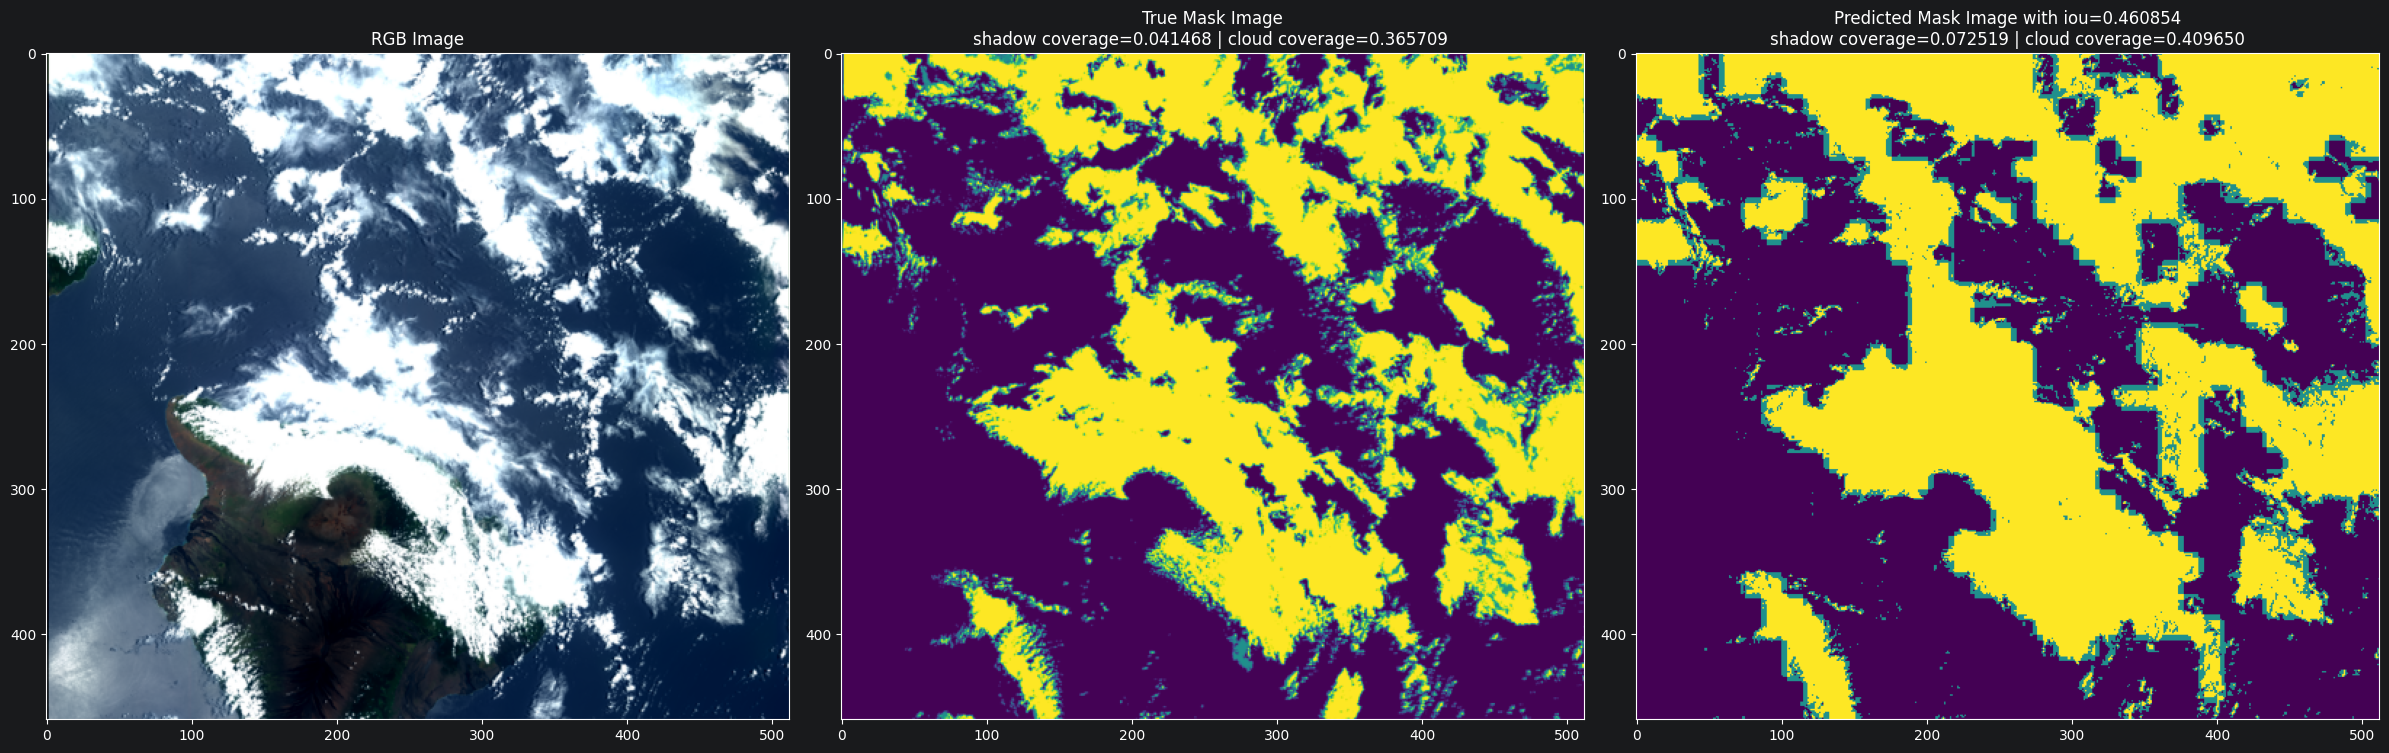

In [190]:
try:
    for data_tif_file in data_tif_files:
        for pred_tif_file in pred_tif_files:
            filename = str(data_tif_file.stem)
            if filename in str(pred_tif_file):
                display_thumbnail_more(data_tif_file, pred_tif_file)
except Exception as e:
    traceback.print_exc()